In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:

# Download or locate dataset path
path = kagglehub.competition_download('porto-seguro-safe-driver-prediction')

train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(path, 'sample_submission.csv'))

In [3]:
train_df.shape

(595212, 59)

In [4]:
train_df.columns

Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin', 'ps_calc_20_bin'],


In [5]:
train_df.describe().round(4)

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.000,595212.0000,...,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000,595212.0000
mean,7.438036e+05,0.0364,1.9004,1.3589,4.4233,0.4168,0.4052,0.3937,0.257,0.1639,...,5.4414,1.4419,2.8723,7.5390,0.1224,0.6278,0.5542,0.2872,0.3490,0.1533
std,4.293678e+05,0.1874,1.9838,0.6646,2.6999,0.4933,1.3506,0.4886,0.437,0.3702,...,2.3329,1.2030,1.6949,2.7467,0.3278,0.4834,0.4971,0.4524,0.4767,0.3603
min,7.000000e+00,0.0000,0.0000,-1.0000,0.0000,-1.0000,-1.0000,0.0000,0.000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,3.719915e+05,0.0000,0.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.000,0.0000,...,4.0000,1.0000,2.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,7.435475e+05,0.0000,1.0000,1.0000,4.0000,0.0000,0.0000,0.0000,0.000,0.0000,...,5.0000,1.0000,3.0000,7.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000
75%,1.115549e+06,0.0000,3.0000,2.0000,6.0000,1.0000,0.0000,1.0000,1.000,0.0000,...,7.0000,2.0000,4.0000,9.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000
max,1.488027e+06,1.0000,7.0000,4.0000,11.0000,1.0000,6.0000,1.0000,1.000,1.0000,...,19.0000,10.0000,13.0000,23.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [6]:
train_df = train_df.replace(-1, np.nan)
test_df = test_df.replace(-1, np.nan)

In [7]:
import pandas as pd

# 1. Генерируем новые бинарные признаки
for df in [train_df, test_df]:
    df["ps_car_11_cat_104"] = (df["ps_car_11_cat"] == 104).astype(int)
    df["ps_ind_05_cat_0"] = (df["ps_ind_05_cat"] == 0).astype(int)
    df["ps_car_04_cat_0"] = (df["ps_car_04_cat"] == 0).astype(int)
    df["ps_car_07_cat_1"] = (df["ps_car_07_cat"] == 1).astype(int)

# 2. Выделяем таргет и список всех признаков
target = train_df['target']
# Задаем фичи, явно исключая id, target и все ps_calc_*
features = [
    c for c in train_df.columns 
    if c not in ['id', 'target'] and not c.startswith('ps_calc_')
]

# 3. Разделяем признаки по типам
cat_cols = [
    c for c in features 
    if c.endswith("_cat") and not any(c.endswith(s) for s in ["_104", "_0", "_1", "_interaction"])
]

bin_cols = [
    c for c in features 
    if c.endswith("_bin") or any(c.endswith(s) for s in ["_104", "_0", "_1"])
]

num_cols = [c for c in features if c not in cat_cols and c not in bin_cols]



Признаков до OHE: 61
Признаков после OHE: 208
Бинарных признаков сохранено: 21


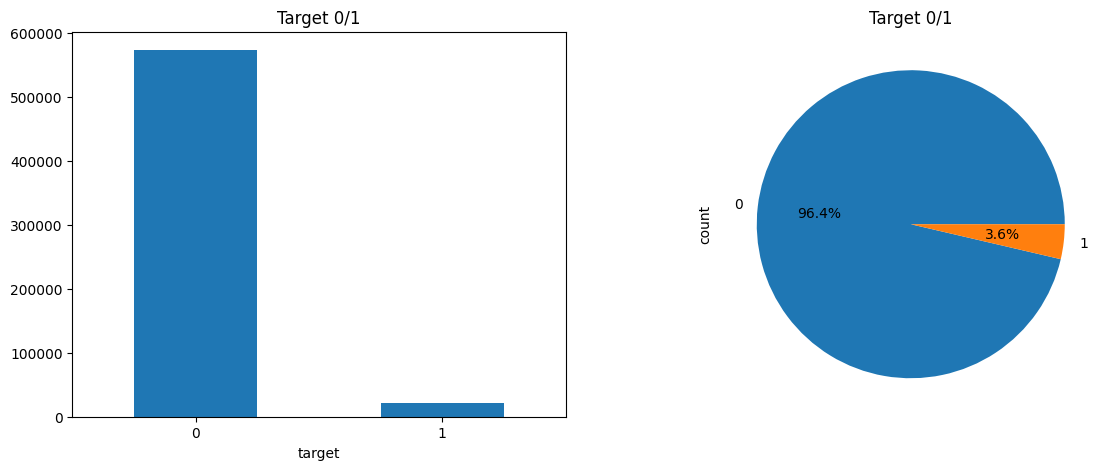

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target.value_counts().plot.bar(ax=axes[0])
axes[0].set_title("Target 0/1")
axes[0].tick_params(axis='x', rotation=0)

target.value_counts().plot.pie(ax=axes[1],  autopct='%1.1f%%')
axes[1].set_title("Target 0/1")
axes[1].tick_params(axis='x', rotation=45)

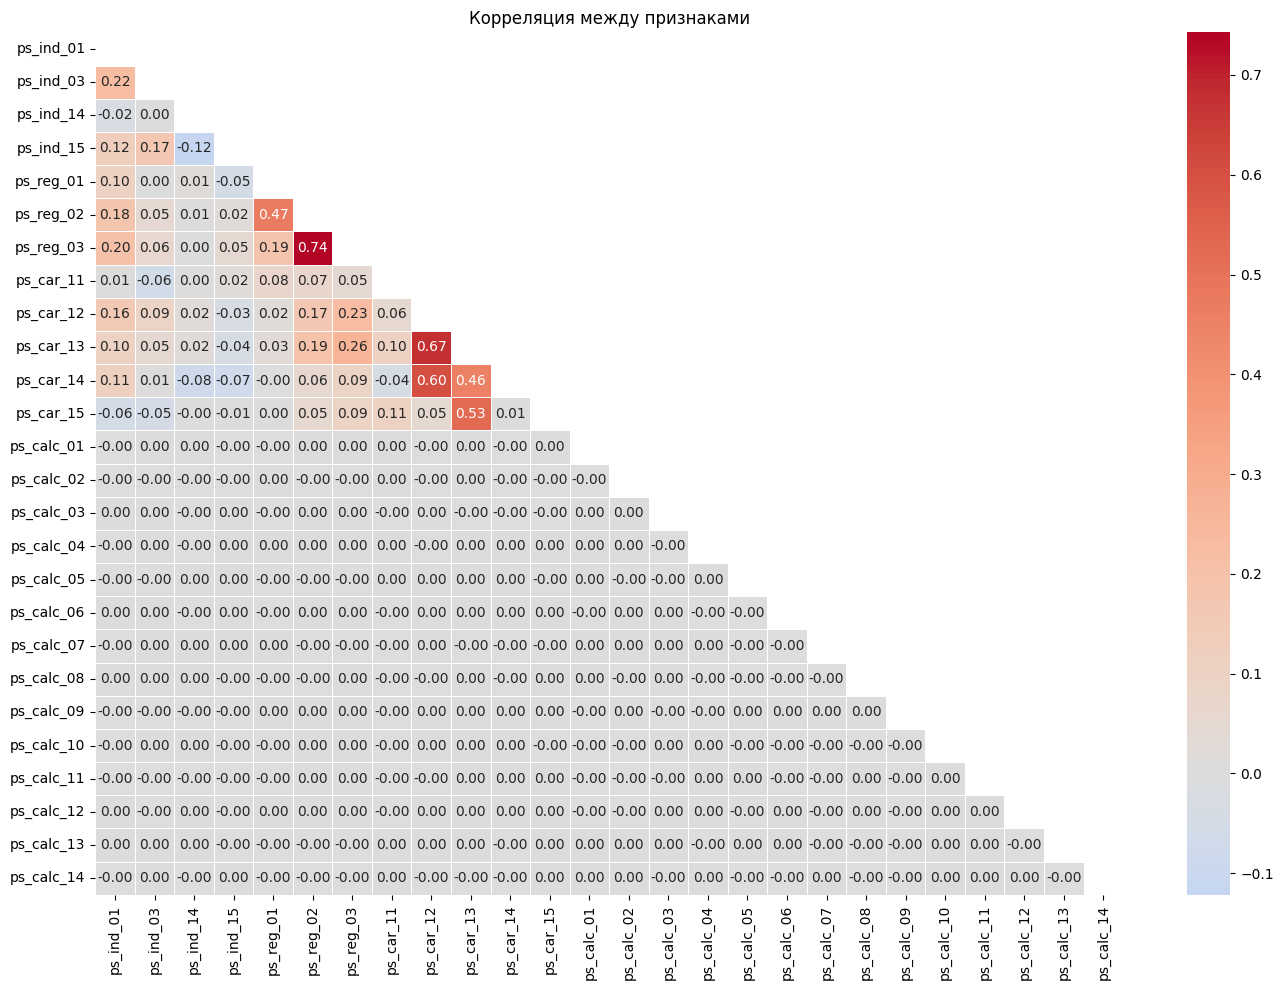

In [9]:
plt.figure(figsize=(14, 10))
corr = train_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

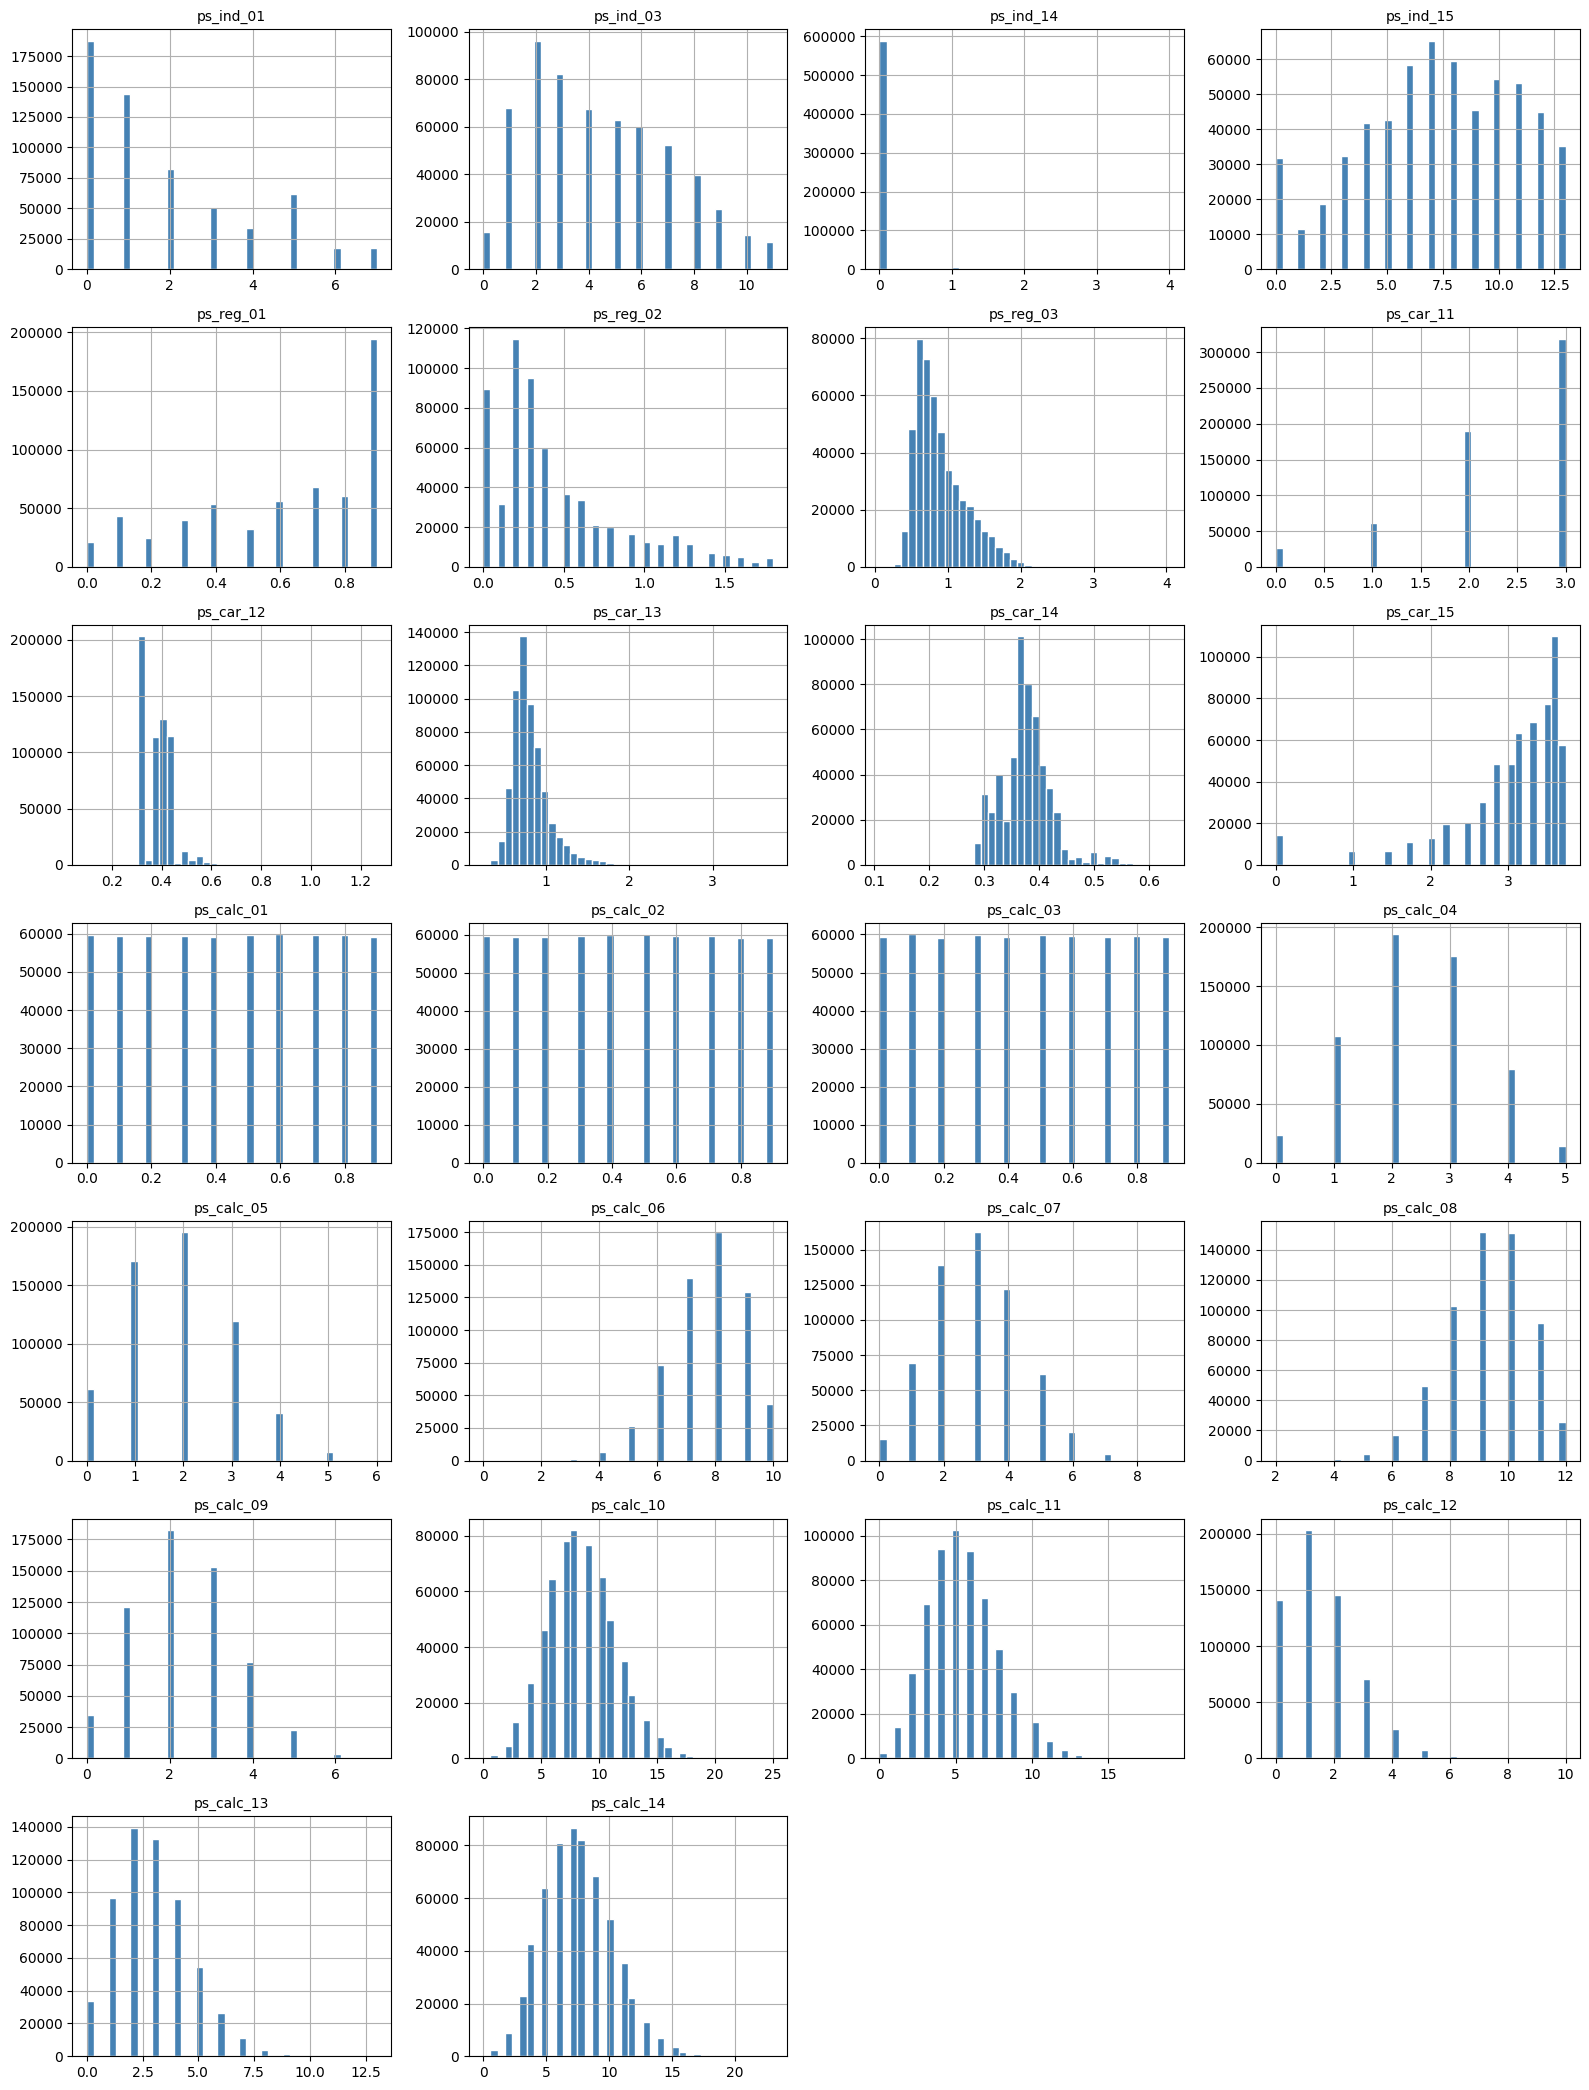

In [10]:
n_cols = len(num_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    train_df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Выброс в ps_car_11_cat, ps_ind_05_cat?
много пропусков в ps_car_03_cat, ps_car_05_cat

**Гипотеза: вынос ps_car_11_cat аномалии в отдельный признак повысит корреляцию признаков и их разделимость**

ПОДТВЕРЖДЕНА

In [11]:
print(train_df["ps_car_11_cat"].value_counts().head(5))

ps_car_11_cat
104    85083
103    24262
64     22278
87     17106
32     12578
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split


In [ ]:
def eval_gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) - 1


In [ ]:
X = train_df[features].copy()
y = train_df['target'].copy()
X_test = test_df[features].copy()

# Версия для CatBoost: категориальные признаки как строки
X_cat = X.copy()
X_test_cat = X_test.copy()
for col in cat_cols:
    X_cat[col] = X_cat[col].fillna('missing').astype(str)
    X_test_cat[col] = X_test_cat[col].fillna('missing').astype(str)
cat_features_idx = [X_cat.columns.get_loc(c) for c in cat_cols]

# Версия для LightGBM и XGBoost: категориальные признаки как category dtype.
# Важно: после replace(-1, np.nan) эти колонки стали float64, поэтому
# сначала заполняем пропуски целочисленным кодом и приводим к int,
# и только потом к category — иначе XGBoost падает с ошибкой
# "Category index from DataFrame has floating point dtype".
X_lgb = X.copy()
X_test_lgb = X_test.copy()
X_xgb = X.copy()
X_test_xgb = X_test.copy()
for col in cat_cols:
    X_lgb[col] = X_lgb[col].fillna(-1).astype(int).astype('category')
    X_test_lgb[col] = X_test_lgb[col].fillna(-1).astype(int).astype('category')
    X_xgb[col] = X_xgb[col].fillna(-1).astype(int).astype('category')
    X_test_xgb[col] = X_test_xgb[col].fillna(-1).astype(int).astype('category')


In [ ]:
base_models = {
    'lgb': LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.03,
        random_state=42,
    ),
    'xgb': XGBClassifier(
        n_estimators=5000,
        learning_rate=0.03,
        tree_method='hist',
        enable_categorical=True,
        eval_metric='auc',
        early_stopping_rounds=200,
        random_state=42,
    ),
    'cat': CatBoostClassifier(
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        cat_features=cat_features_idx,
        eval_metric='AUC',
        random_seed=42,
        verbose=200,
        early_stopping_rounds=200,
    ),
}

# Какой набор данных (train/test) использовать для каждой модели
model_data = {
    'lgb': (X_lgb, X_test_lgb),
    'xgb': (X_xgb, X_test_xgb),
    'cat': (X_cat, X_test_cat),
}

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_train = np.zeros((len(X), len(base_models)))
oof_test = np.zeros((len(X_test), len(base_models)))

for model_idx, (name, model) in enumerate(base_models.items()):
    print(f"--- Обучение базовой модели: {name} ---")
    X_model, X_test_model = model_data[name]
    test_preds_folds = np.zeros((len(X_test_model), n_splits))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_model, y)):
        X_tr, y_tr = X_model.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X_model.iloc[val_idx], y.iloc[val_idx]

        if name == 'lgb':
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(200, verbose=False)],
            )
        elif name == 'xgb':
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        else:  # catboost
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

        oof_train[val_idx, model_idx] = model.predict_proba(X_va)[:, 1]
        test_preds_folds[:, fold] = model.predict_proba(X_test_model)[:, 1]

    oof_test[:, model_idx] = test_preds_folds.mean(axis=1)

    score = roc_auc_score(y, oof_train[:, model_idx])
    gini = eval_gini(y, oof_train[:, model_idx])
    print(f"OOF ROC-AUC для {name}: {score:.5f}, Gini: {gini:.5f}\n")

print("--- Обучение мета-модели ---")
meta_model = LogisticRegression(C=0.1, random_state=42)
meta_model.fit(oof_train, y)

final_oof_preds = meta_model.predict_proba(oof_train)[:, 1]
final_auc = roc_auc_score(y, final_oof_preds)
print(f"Итоговый OOF ROC-AUC ансамбля: {final_auc:.5f}")
print(f"Итоговый OOF Gini ансамбля: {eval_gini(y, final_oof_preds):.5f}")

final_test_preds = meta_model.predict_proba(oof_test)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'target': final_test_preds
})
submission.to_csv('submission_oof_blending.csv', index=False)
submission.head()
